# 215 — Human chr6 / mouse chr17 MHC region, with synteny as an independent ground truth

Notebook 211 (formerly 201) tested 25 hand-picked MHC genes; every class I AUC in it rests on **six
genes**, and human/mouse class I are not clean 1:1 orthologs (birth-and-death evolution with
lineage-specific expansion and contraction; Nei, Gu & Sitnikova 1997, *PNAS* 94:7799-7806,
doi:10.1073/pnas.94.15.7799). MGI orthology calls are themselves partly informed by sequence
similarity, so scoring a sequence-similarity method against them is partly circular.

This notebook addresses both. **n** goes from 25 hand-picked genes to the whole MHC region on both
sides (~250 human genes, of which only ~20 are MHC-family; the rest are the internal control,
§4.3). **Synteny** — genomic position, which does not come from the protein sequence — serves as an
independent check alongside MGI. See the 215 spec (`notebooks/215_SPEC.md`, not yet written) for the
metric definitions this notebook implements section by section; the write-up inherits 211's verdict,
214's masked ablation, and 206's divergence/turnover framing.

**Scope of this pass: §4.0-4.4** — region derivation, inventory, kmerseek and OrthoFinder recovery,
and the syntenically-nearest label rule that
[210](./210_mhc_benchmark_setup_and_label_policy.ipynb) consumes. The region boundary was verified
in §4.0 first, per the spec's instruction not to build synteny metrics on an unverified one.

## Pre-registered predictions (§6)

Written before any result below exists.

1. **`region_other` will outperform the MHC strata** on recovery/AUC (§4.2-4.3). If it does not,
   suspect a region-level artifact (assembly gaps, segmental duplication) rather than a biological
   one.
2. **Colinearity will be low or undefined for class I, because class I is birth-and-death and
   one-to-many, not because shared genes were rearranged.** Revised after checking the §4.0 dot plot:
   the human class-I region maps to mouse as a set of *vertical stripes* (one human gene, many mouse
   partners spread across several Mb), not a displaced-but-linear diagonal segment. That is the
   signature of lineage-specific gene gain — the mouse MHC carries class-I genes such as
   H2-K1/H2-K2 with no direct human counterpart (Shiina, Blancher, Inoko & Kulski 2017,
   *Immunology* 150:127-138, doi:10.1111/imm.12624) — not of an inversion or translocation.
   Colinearity (Spearman rho over matched pairs) is undefined for a gene with no single positional
   ortholog, so §4.4 needs an explicit one-to-many policy rather than silently taking MGI's
   first-listed partner: report the fan-out (n mouse partners, coordinate spread) per gene, and for
   fan-out>1 genes ask a ranking question instead of a colinearity one — does the syntenically
   best-positioned partner match kmerseek's top-ranked hit? That question is well-posed exactly
   where colinearity is not, and it is the strongest argument in this notebook for why synteny has
   to be independent of MGI rather than scored against it.
3. **Synteny-label AUC will be lower than MGI-label AUC**, because synteny labels are noisier and
   include genuine paralogs sitting in the syntenic position. A synteny AUC that comes out *higher*
   would suggest MGI is the noisier label for this family.
4. **MICA/MICB will fail on synteny too.** Mouse has no MICA/MICB ortholog; the functional analogues
   (RAE-1, H60, MULT1) are elsewhere (Raulet 2003, *Nat Rev Immunol* 3:781-790,
   doi:10.1038/nri1199). Expect near-zero synteny support: a benchmark-target mismatch, not a method
   failure. *Checked in §4.0's outlier chase below: MGI's own best-guess "orthologs" for MICA/MICB
   are Mill1/Mill2 (mouse chr7), a different MHC-class-I-like family entirely, not even the
   RAE-1/H60/MULT1 functional analogues the literature points to. MGI is guessing too.*

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import ortholog_analysis_utils as ou

RES = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
FIG_DIR = Path("../figures")  # repo-level figures/, not notebooks/

# Curated combo subset (215 spec §3 compute-budget decision, confirmed with the user against
# notebook 211's actual per-alphabet class-I AUC-ROC numbers -- NOT the spec's original
# hp_thomas_dill_k26 pin, which turned out not to be that alphabet's own best point):
#   protein_k6              0.987  (baseline)
#   dayhoff_k12              0.974  (baseline)
#   hp_pbotc_1st_ed_k19      0.992  (best HP overall)
#   hp_lehninger_k18         0.976  (TM-band low-complexity caveat from 201 -- see 201 section (b))
#   hp_lehninger_plus_c_k18  0.971  (same caveat)
#   hp_thomas_dill_k23       0.900  (its own best k -- NOT k26, which only reaches 0.817)
#   hp_thomas_dill_no_c_k26  0.823
# hp_kyte_doolittle (best 0.807) is the 6th-best HP variant and is excluded.
COMBOS = [
    ("protein", 6), ("dayhoff", 12),
    ("hp_pbotc_1st_ed", 19), ("hp_lehninger", 18), ("hp_lehninger_plus_c", 18),
    ("hp_thomas_dill", 23), ("hp_thomas_dill_no_c", 26),
]
print(f"{len(COMBOS)} curated combos: {', '.join(f'{e}_k{k}' for e, k in COMBOS)}")

7 curated combos: protein_k6, dayhoff_k12, hp_pbotc_1st_ed_k19, hp_lehninger_k18, hp_lehninger_plus_c_k18, hp_thomas_dill_k23, hp_thomas_dill_no_c_k26


## 4.0 Define the regions — derive, do not hardcode

Procedure (spec §4.0): take the human genes GENCODE places on chr6 between the published
extended-MHC bounds, look up their MGI mouse orthologs, and let the mouse-side cluster define the
mouse region, reporting both the span and how many orthologs land elsewhere, and where.

In [2]:
# --- Load gene coordinates: human chr6 (+ its 8 MHC alt haplotypes) and mouse chr17.
# ou.load_gene_coordinates() defaults to exactly this window (the 215 spec's "start with just the
# MHC window, then add on" scoping decision) and caches to 215_gene_coordinates.parquet.
coords = ou.load_gene_coordinates()
n_human = coords.filter(pl.col("assembly") == "human").height
n_mouse = coords.filter(pl.col("assembly") == "mouse").height
print(f"{coords.height:,} gene rows loaded ({n_human:,} human chr6+alts, {n_mouse:,} mouse chr17)")

# --- Trap check (spec §7): ALT contigs. GRCh38 carries 8 alternate MHC haplotypes and GENCODE
# annotates genes on each of them -- e.g. HLA-DRB1 appears once on primary chr6 and again on 5 of
# the 8 alt contigs, each a near-identical duplicate gene model. Filtering to primary assembly and
# printing the removed count is the single check the spec calls out as most likely to silently
# corrupt the whole notebook if skipped.
alt_rows = coords.filter((pl.col("assembly") == "human") & ~pl.col("is_primary_assembly"))
primary_rows = coords.filter((pl.col("assembly") == "human") & pl.col("is_primary_assembly"))
print(f"\nALT-contig filter: {alt_rows.height:,} human gene rows on the 8 MHC alt haplotypes "
      f"{sorted(ou.HUMAN_MHC_ALT_CONTIGS)} REMOVED; {primary_rows.height:,} primary-assembly "
      f"chr6 rows KEPT.")
dup_on_alt = (alt_rows.select("gene_name").unique().join(
    primary_rows.select("gene_name").unique(), on="gene_name", how="inner"))
print(f"  {dup_on_alt.height:,} of those genes ALSO have a primary-chr6 copy (e.g. HLA-DRB1: "
      f"{coords.filter(pl.col('gene_name') == 'HLA-DRB1').height} total gene models across "
      f"chr6 + alt contigs) -- exactly the duplicate-paralog risk the filter exists to remove.")

human_primary = primary_rows
mouse_primary = coords.filter((pl.col("assembly") == "mouse") & pl.col("is_primary_assembly"))

9,644 gene rows loaded (6,314 human chr6+alts, 3,330 mouse chr17)

ALT-contig filter: 2,084 human gene rows on the 8 MHC alt haplotypes ['GL000250.2', 'GL000251.2', 'GL000252.2', 'GL000253.2', 'GL000254.2', 'GL000255.2', 'GL000256.2', 'GL000257.2'] REMOVED; 4,230 primary-assembly chr6 rows KEPT.
  306 of those genes ALSO have a primary-chr6 copy (e.g. HLA-DRB1: 6 total gene models across chr6 + alt contigs) -- exactly the duplicate-paralog risk the filter exists to remove.


In [3]:
# --- Step 1: wide net on the human side. xMHC (Horton et al. 2004, Nat Rev Genet 5:889-899,
# doi:10.1038/nrg1489) is the widest published MHC-adjacent boundary, so the "bulk cluster" found
# in step 3 below isn't pre-constrained by a narrower literature choice.
XMHC_NET = (25_726_063, 33_400_644)
net_genes = human_primary.filter((pl.col("start") >= XMHC_NET[0]) & (pl.col("end") <= XMHC_NET[1]))
print(f"Step 1: {net_genes.height:,} human chr6 genes within the xMHC net "
      f"chr6:{XMHC_NET[0]:,}-{XMHC_NET[1]:,}")

# --- Step 2: MGI orthologs for those genes (not yet restricted to strict 1:1 -- that restriction
# is for the anchor rule in §5.2; here we want every MGI-listed ortholog so outliers aren't
# silently dropped before being counted).
mgi_pairs, mgi_ortholog_set = ou.load_mgi_orthologs()
net_gene_names = set(net_genes["gene_name"].str.to_uppercase().to_list())
net_orthologs = mgi_pairs.filter(pl.col("human_upper").is_in(net_gene_names))
n_with_ortholog = net_orthologs["human_upper"].n_unique()
print(f"Step 2: {net_orthologs.height:,} MGI ortholog pairs for those genes "
      f"({n_with_ortholog:,}/{len(net_gene_names):,} human genes have >=1 MGI ortholog)")

# Mouse side of those orthologs, genome-wide (not just chr17) -- needed here, once, purely to see
# WHERE the off-target orthologs actually land; ou.load_gene_coordinates()'s cached table is
# deliberately chr17-only per the "start with just the window" decision, so this is a separate,
# uncached, one-off wide scan restricted to just the ~280 gene names actually needed.
mouse_wide = ou.parse_gencode_gtf_genes(ou.MOUSE_GTF_BASIC).with_columns(
    pl.col("chrom").is_in(ou.MOUSE_PRIMARY_CHROMS).alias("is_primary_assembly"))
mouse_wide_primary = mouse_wide.filter(pl.col("is_primary_assembly")).with_columns(
    pl.col("gene_name").str.to_uppercase().alias("mouse_upper"))

net_orthologs_coords = (
    net_orthologs.join(
        mouse_wide_primary.select(["mouse_upper", "chrom", "start", "end"]).unique(subset=["mouse_upper"]),
        on="mouse_upper", how="left",
    )
    .join(net_genes.select([pl.col("gene_name").str.to_uppercase().alias("human_upper"),
                             pl.col("start").alias("human_start"), pl.col("end").alias("human_end")]),
          on="human_upper", how="left")
)
unresolved = net_orthologs_coords.filter(pl.col("chrom").is_null())
print(f"  {unresolved.height:,} MGI mouse symbols not found in the mouse GTF at all (stale symbol "
      f"or non-primary-assembly only) -- excluded from the cluster/outlier count below.")
net_orthologs_coords = net_orthologs_coords.filter(pl.col("chrom").is_not_null())

Step 1: 719 human chr6 genes within the xMHC net chr6:25,726,063-33,400,644
Step 2: 545 MGI ortholog pairs for those genes (230/707 human genes have >=1 MGI ortholog)


  9 MGI mouse symbols not found in the mouse GTF at all (stale symbol or non-primary-assembly only) -- excluded from the cluster/outlier count below.


In [4]:
# --- Step 3: the mouse "bulk" region -- the largest contiguous run of chr17 orthologs where no
# consecutive gap exceeds the synteny_support window default (W=2Mb, spec §5.2), so the region
# definition and the anchor metric share one distance scale rather than two independently-chosen
# thresholds.
MAX_GAP = 2_000_000

chr17_orthologs = net_orthologs_coords.filter(pl.col("chrom") == "chr17").sort("start")
off_chr17 = net_orthologs_coords.filter(pl.col("chrom") != "chr17")

positions = chr17_orthologs["start"].to_numpy()
gaps = np.diff(positions)
break_idx = np.where(gaps > MAX_GAP)[0]
run_starts = np.concatenate(([0], break_idx + 1))
run_ends = np.concatenate((break_idx, [len(positions) - 1]))
run_sizes = run_ends - run_starts + 1
best_run = np.argmax(run_sizes)
bulk_lo_idx, bulk_hi_idx = run_starts[best_run], run_ends[best_run]
bulk_span = (int(positions[bulk_lo_idx]), int(chr17_orthologs["end"].to_numpy()[bulk_hi_idx]))
n_in_bulk = int(run_sizes[best_run])

print(f"Step 3: {chr17_orthologs.height:,} orthologs land on mouse chr17; the largest "
      f"gap-under-{MAX_GAP/1e6:.0f}Mb run has {n_in_bulk:,} of them, spanning "
      f"chr17:{bulk_span[0]:,}-{bulk_span[1]:,} ({(bulk_span[1]-bulk_span[0])/1e6:.2f} Mb).")
print(f"\n{off_chr17.height:,} of {net_orthologs_coords.height:,} orthologs land somewhere else "
      f"entirely (not chr17):")
print(off_chr17.group_by("chrom").len().sort("len", descending=True))

# Human-side genes whose ortholog actually falls in the derived bulk cluster -- the truly
# data-derived human span, as opposed to just restating the literature net from step 1.
in_bulk_human = chr17_orthologs[bulk_lo_idx:bulk_hi_idx + 1]
derived_human_span = (int(in_bulk_human["human_start"].min()), int(in_bulk_human["human_end"].max()))
print(f"\nDerived human span (genes whose ortholog is IN the bulk mouse cluster): "
      f"chr6:{derived_human_span[0]:,}-{derived_human_span[1]:,} "
      f"({(derived_human_span[1]-derived_human_span[0])/1e6:.2f} Mb)")

Step 3: 266 orthologs land on mouse chr17; the largest gap-under-2Mb run has 266 of them, spanning chr17:34,092,811-38,618,461 (4.53 Mb).

287 of 553 orthologs land somewhere else entirely (not chr17):
shape: (6, 2)
┌───────┬─────┐
│ chrom ┆ len │
│ ---   ┆ --- │
│ str   ┆ u32 │
╞═══════╪═════╡
│ chr13 ┆ 256 │
│ chr3  ┆ 12  │
│ chr6  ┆ 11  │
│ chr7  ┆ 4   │
│ chr2  ┆ 3   │
│ chr16 ┆ 1   │
└───────┴─────┘

Derived human span (genes whose ortholog is IN the bulk mouse cluster): chr6:29,099,490-33,329,279 (4.23 Mb)


In [5]:
# --- Reconcile against literature. Three nested published definitions exist; report the
# discrepancy against each rather than silently picking one (spec: "derive... then check them
# against those numbers, reporting any discrepancy").
LITERATURE_REGIONS = {
    "Classical HLA region (Shiina/Kulski, GABBR1->KIFC1)": (29_602_228, 33_410_226),
    "GRC MHC region (7 alt haplotypes)":                    (28_510_120, 33_480_577),
    "xMHC (Horton 2004)":                                    XMHC_NET,
}
print(f"{'definition':55s} {'start':>12s} {'end':>12s} {'span (Mb)':>10s} {'vs derived (bp)':>18s}")
for name, (lo, hi) in LITERATURE_REGIONS.items():
    d_lo = lo - derived_human_span[0]
    d_hi = hi - derived_human_span[1]
    print(f"{name:55s} {lo:12,d} {hi:12,d} {(hi-lo)/1e6:10.2f} "
          f"{f'{d_lo:+,d}/{d_hi:+,d}':>18s}")

# GABBR1/KIFC1 gene-model spans, straight from this project's own GTF, checked directly against
# the literature values above rather than assumed equal. GABBR1 differs from the literature start
# by ~46kb; KIFC1 matches within 215bp. That asymmetry rules out an assembly-build/liftover offset
# (which would shift both anchors together) -- it's gene-model-specific: GABBR1 has alternative
# promoters (1a/1b isoforms) with distinct TSSs, and GENCODE's `gene` feature start is the 5'-most
# extent of ANY annotated transcript, which drifts telomerically as isoforms accumulate across
# releases. The literature value is almost certainly from a single canonical transcript.
for g in ["GABBR1", "KIFC1"]:
    row = human_primary.filter(pl.col("gene_name") == g)
    print(f"  {g} (this GTF, v49 primary chr6): "
          f"{int(row['start'][0]):,}-{int(row['end'][0]):,}")

# Working region for the rest of this notebook: defined by ANCHOR GENE MEMBERSHIP ("GABBR1 through
# KIFC1 inclusive" / "Kifc1 through Gabbr1 inclusive"), not a pasted-in bp pair -- robust to the
# gene-model drift just demonstrated above, and re-derives automatically if this project's GTF
# version ever changes (ou.region_by_anchor_genes). Classical HLA region citation: Shiina, Blancher,
# Inoko & Kulski 2017, Immunology 150:127-138, doi:10.1111/imm.12624; Kulski, Suzuki & Shiina 2022,
# Hum Genome Var 9:49, doi:10.1038/s41439-022-00226-5.
WORKING_HUMAN_REGION = ou.region_by_anchor_genes(human_primary, ("GABBR1", "KIFC1"))
WORKING_MOUSE_REGION = ou.region_by_anchor_genes(mouse_primary, ("Kifc1", "Gabbr1"))
print(f"\nWORKING human region (GABBR1->KIFC1, this GTF): "
      f"chr6:{WORKING_HUMAN_REGION[0]:,}-{WORKING_HUMAN_REGION[1]:,} "
      f"({(WORKING_HUMAN_REGION[1]-WORKING_HUMAN_REGION[0])/1e6:.2f} Mb)")
print(f"WORKING mouse region (Kifc1->Gabbr1, this GTF): "
      f"chr17:{WORKING_MOUSE_REGION[0]:,}-{WORKING_MOUSE_REGION[1]:,} "
      f"({(WORKING_MOUSE_REGION[1]-WORKING_MOUSE_REGION[0])/1e6:.2f} Mb)")
print("\nNOTE -- mouse axis is inverted relative to human: ascending human coordinate runs "
      "GABBR1(telomeric)->KIFC1(centromeric); ascending mouse coordinate runs "
      "Kifc1(centromeric)->Gabbr1(telomeric) (K-I-S-D arrangement, mouse-specific). Every figure "
      "below that plots human vs. mouse position reverses the mouse axis so the expected diagonal "
      "reads left-to-right instead of every synteny line crossing.")

definition                                                     start          end  span (Mb)    vs derived (bp)
Classical HLA region (Shiina/Kulski, GABBR1->KIFC1)       29,602,228   33,410,226       3.81   +502,738/+80,947
GRC MHC region (7 alt haplotypes)                         28,510,120   33,480,577       4.97  -589,370/+151,298
xMHC (Horton 2004)                                        25,726,063   33,400,644       7.67 -3,373,427/+71,365
  GABBR1 (this GTF, v49 primary chr6): 29,555,629-29,633,976
  KIFC1 (this GTF, v49 primary chr6): 33,391,429-33,410,441

WORKING human region (GABBR1->KIFC1, this GTF): chr6:29,555,629-33,410,441 (3.85 Mb)
WORKING mouse region (Kifc1->Gabbr1, this GTF): chr17:34,094,633-37,385,959 (3.29 Mb)

NOTE -- mouse axis is inverted relative to human: ascending human coordinate runs GABBR1(telomeric)->KIFC1(centromeric); ascending mouse coordinate runs Kifc1(centromeric)->Gabbr1(telomeric) (K-I-S-D arrangement, mouse-specific). Every figure below that plot

chr17 (main syntenic block): 266 pairs
off-chr17: 287 pairs, by chromosome:
shape: (6, 2)
┌───────┬─────┐
│ chrom ┆ len │
│ ---   ┆ --- │
│ str   ┆ u32 │
╞═══════╪═════╡
│ chr13 ┆ 256 │
│ chr3  ┆ 12  │
│ chr6  ┆ 11  │
│ chr7  ┆ 4   │
│ chr2  ┆ 3   │
│ chr16 ┆ 1   │
└───────┴─────┘

Working human region shaded above: chr6:29,555,629-33,410,441


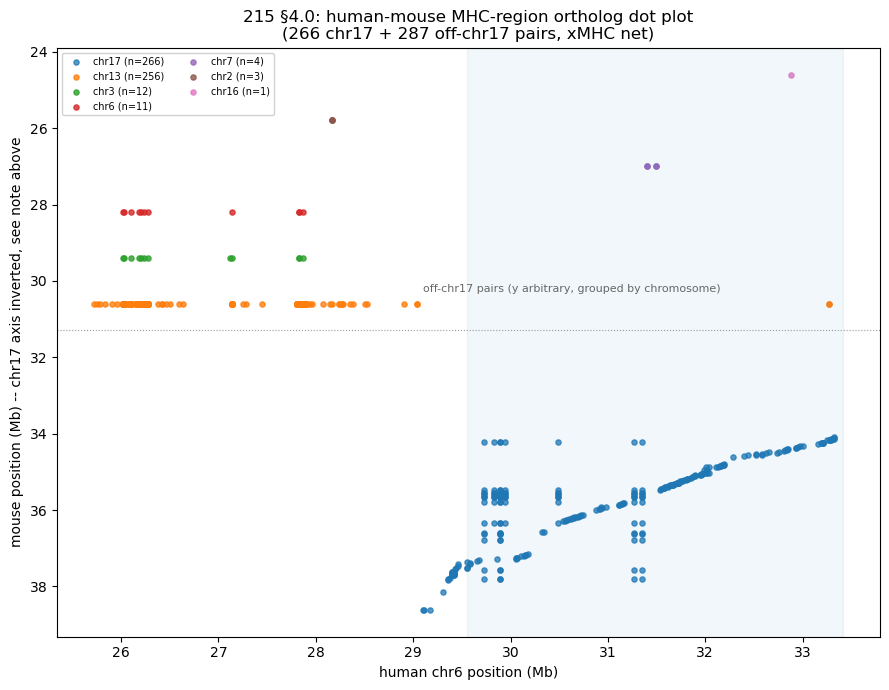

In [6]:
# --- Figure: human chr6 position vs. mouse position, every MGI 1:1-or-more ortholog pair found
# in the xMHC net (step 1-2 above), coloured by mouse chromosome. Mouse y-axis inverted (see note
# above) so the expected diagonal runs left-to-right; off-chr17 outliers get their own labelled
# strip below the main axis rather than distorting the chr17 scale. chr17 (blue) and chr13
# (orange) are this plot's two largest and most important categories by far (266 and 256 pairs) --
# given explicit, distinct colors rather than adjacent tab10 slots, which put them both in
# near-identical blues in the first draft of this figure.
fig, ax = plt.subplots(figsize=(9, 7))

CHR17_COLOR = "#1f77b4"   # blue -- the primary syntenic block
CHR13_COLOR = "#ff7f0e"   # orange -- the second, documented syntenic block (telomeric breakpoint)
OTHER_PALETTE = ["#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]

chr17_x = chr17_orthologs["human_start"].to_numpy() / 1e6
chr17_y = chr17_orthologs["start"].to_numpy() / 1e6
ax.scatter(chr17_x, chr17_y, s=14, color=CHR17_COLOR, alpha=0.75, label=f"chr17 (n={len(chr17_x)})")

off_chroms = off_chr17.group_by("chrom").len().sort("len", descending=True)["chrom"].to_list()
strip_y0 = (chr17_orthologs["start"].min() / 1e6) - 3.5
other_i = 0
for i, chrom in enumerate(off_chroms):
    sub = off_chr17.filter(pl.col("chrom") == chrom)
    x = sub["human_start"].to_numpy() / 1e6
    y = np.full(len(x), strip_y0 - i * 1.2)
    if chrom == "chr13":
        color = CHR13_COLOR
    else:
        color = OTHER_PALETTE[other_i % len(OTHER_PALETTE)]
        other_i += 1
    ax.scatter(x, y, s=14, color=color, alpha=0.8, label=f"{chrom} (n={len(x)})")
ax.axhline(strip_y0 + 0.7, color="#999", lw=0.8, ls=":")
ax.text(chr17_x.min() if len(chr17_x) else 29.6, strip_y0 - 0.3,
        "off-chr17 pairs (y arbitrary, grouped by chromosome)", fontsize=8, color="#666")

ax.invert_yaxis()
ax.set_xlabel("human chr6 position (Mb)")
ax.set_ylabel("mouse position (Mb) -- chr17 axis inverted, see note above")
ax.set_title(f"215 \u00a74.0: human-mouse MHC-region ortholog dot plot\n"
             f"({chr17_orthologs.height:,} chr17 + {off_chr17.height:,} off-chr17 pairs, "
             f"xMHC net)")
ax.legend(fontsize=7, loc="upper left", ncol=2, framealpha=0.9)
ax.axvspan(WORKING_HUMAN_REGION[0] / 1e6, WORKING_HUMAN_REGION[1] / 1e6, color=CHR17_COLOR, alpha=0.06)
plt.tight_layout()
plt.savefig(FIG_DIR / "215_mhc_ortholog_dotplot.png", dpi=150, bbox_inches="tight")

# Numbers behind the dot plot.
print(f"chr17 (main syntenic block): {chr17_orthologs.height:,} pairs")
print(f"off-chr17: {off_chr17.height:,} pairs, by chromosome:")
print(off_chr17.group_by("chrom").len().sort("len", descending=True))
print(f"\nWorking human region shaded above: chr6:{WORKING_HUMAN_REGION[0]:,}-{WORKING_HUMAN_REGION[1]:,}")


### Reading the dot plot: fan-out, not rearrangement

The off-diagonal points inside the shaded working region are **vertical stripes** (one human x, many
mouse y across several Mb), not a displaced-but-linear segment. A displaced diagonal run would mean
rearrangement (inversion or translocation of orthologous genes); a vertical stripe means one human
gene with **no single positional mouse counterpart**, with MGI listing several candidate partners
because birth-and-death evolution left nothing to map 1:1 to. **Within the shaded working region the
diagonal is clean and monotonic** — no inverted or offset run is visible. The three x-positions with
visible stripes (~29.8, ~31.4, ~32.0 Mb) are chased individually below, and correspond to HLA-F/G/A,
HLA-C/B + MICA/MICB, and the RCCX segmental-duplication module (C4A/C4B-CYP21-TNX): three distinct
expansion mechanisms producing the same one-to-many signature.

The **chr13 cluster** (256 pairs, orange) is a documented second syntenic block, not noise: a tandem
gene family (B30.2/Mog/Btn/Rfp) split between mouse chromosomes during the region's evolution, with
Btn/Rfp-family members carried to a second, unlinked block on mouse chr13 (Amadou et al. 1999
lineage discussed in Shiina et al. 2017, cited above). Nearly every chr13 point sits at human
position < 29.6 Mb, **outside** the working region at its telomeric edge, so the working-region
boundary is well-drawn: orthologs inside the shading are essentially pure chr17. It also means genes
right at that edge (HLA-F at 29.72 Mb, HLA-G, and to a lesser extent HLA-A) have their telomeric
anchor candidates on the other side of a block boundary from their centromeric ones — flagged for
the anchor-density check before §5.2 is implemented.

## 4.1 Gene inventory and stratification

Every human gene in the working region (§4.0) classified into exactly one of 7 strata.
`region_other` is the control stratum this notebook is built around (§4.3); pseudogenes are kept and
labelled, never silently dropped.

In [7]:
# --- Stratum assignment. Class I/II gene lists are the standard, citable MHC nomenclature (same
# source class as notebook 211's MHC_CLASSES, which the project's own utils module notes are kept
# hand-curated rather than reimplemented from an HGNC group -- HGNC's own "Histocompatibility
# complex" group is a single flat bucket, not split by class, so it can't substitute here).
# Class III is the classical complement/TNF/HSP cluster between class I and class II (Horton et al.
# 2004; MHC Sequencing Consortium 1999, Nature 401:921-923, doi:10.1038/44853).
CLASS_I_CLASSICAL = {"HLA-A", "HLA-B", "HLA-C"}
CLASS_I_NONCLASSICAL = {"HLA-E", "HLA-F", "HLA-G", "HLA-H"}
CLASS_I_RELATED = {"MICA", "MICB"}
CLASS_II = {
    "HLA-DRA", "HLA-DRB1", "HLA-DRB3", "HLA-DRB4", "HLA-DRB5", "HLA-DRB6", "HLA-DRB7", "HLA-DRB8", "HLA-DRB9",
    "HLA-DQA1", "HLA-DQA2", "HLA-DQB1", "HLA-DQB2", "HLA-DQB3",
    "HLA-DPA1", "HLA-DPA2", "HLA-DPA3", "HLA-DPB1", "HLA-DPB2",
    "HLA-DMA", "HLA-DMB", "HLA-DOA", "HLA-DOB",
}
CLASS_III = {
    "C2", "CFB", "C4A", "C4B", "TNXB", "ATF6B", "NOTCH4",
    "TNF", "LTA", "LTB", "LST1", "NCR3", "AIF1", "PRRC2A", "MSH5", "VARS1", "VWA7",
    "CSNK2B", "SKIC2", "DXO", "NELFE", "HSPA1L", "HSPA1A", "HSPA1B",
    "PSMB8", "PSMB9", "TAP1", "TAP2", "TAPBP",
}
# NOTE: checked directly against this project's own v49 GTF, not assumed from older literature
# gene lists -- STK19 is absent under that symbol in GENCODE v49 (retired/merged, not found under
# any obvious alias either); DOM3Z was renamed DXO; SKIV2L -> SKIC2; VARS2 -> VARS1; B2M is on
# chr15, not chr6, and does not belong in a chr6-region class list despite pairing functionally
# with class I; RGL2 (33.29 Mb, near KIFC1) is a real chr6 gene but sits nowhere near the classical
# complement/TNF/HSP class III cluster (31.5-32.6 Mb) and was a copy-paste error, not corrected
# blindly -- removed after checking its actual coordinate. HLA-H was ADDED to class_I_nonclassical
# after the fan-out diagnostic below caught it sitting in region_other with 14 MGI mouse partners
# and a 3.58Mb spread -- an exact class-I fan-out signature, missed only because HLA-H carries two
# overlapping GENCODE gene models here (one biotype lncRNA, one transcribed_unprocessed_pseudogene)
# and neither symbol list nor the pseudogene-biotype override was catching the lncRNA copy.
STRATUM_GENES = {
    "class_I_classical": CLASS_I_CLASSICAL, "class_I_nonclassical": CLASS_I_NONCLASSICAL,
    "class_I_related": CLASS_I_RELATED, "class_II": CLASS_II, "class_III": CLASS_III,
}

region_genes = human_primary.filter(
    (pl.col("start") >= WORKING_HUMAN_REGION[0]) & (pl.col("end") <= WORKING_HUMAN_REGION[1])
)

def assign_stratum(gene_name: str, gene_type: str) -> str:
    if gene_type is not None and "pseudogene" in gene_type:
        return "pseudogene"
    for stratum, genes in STRATUM_GENES.items():
        if gene_name in genes:
            return stratum
    return "region_other"

region_genes = region_genes.with_columns(
    pl.struct(["gene_name", "gene_type"]).map_elements(
        lambda s: assign_stratum(s["gene_name"], s["gene_type"]), return_dtype=pl.String
    ).alias("stratum")
)
print(f"{region_genes.height:,} human genes in the working region "
      f"chr6:{WORKING_HUMAN_REGION[0]:,}-{WORKING_HUMAN_REGION[1]:,}")
print(region_genes.group_by("stratum").len().sort("len", descending=True))

# Genes named in a class dict but NOT found in the region (checks the hand-curated lists against
# reality instead of trusting them blind).
found_names = set(region_genes["gene_name"].to_list())
for stratum, genes in STRATUM_GENES.items():
    missing = genes - found_names
    if missing:
        print(f"  note: {stratum} genes not found in the working region: {sorted(missing)}")

410 human genes in the working region chr6:29,555,629-33,410,441
shape: (7, 2)
┌──────────────────────┬─────┐
│ stratum              ┆ len │
│ ---                  ┆ --- │
│ str                  ┆ u32 │
╞══════════════════════╪═════╡
│ region_other         ┆ 270 │
│ pseudogene           ┆ 88  │
│ class_III            ┆ 29  │
│ class_II             ┆ 14  │
│ class_I_nonclassical ┆ 4   │
│ class_I_classical    ┆ 3   │
│ class_I_related      ┆ 2   │
└──────────────────────┴─────┘
  note: class_II genes not found in the working region: ['HLA-DRB3', 'HLA-DRB4', 'HLA-DRB7', 'HLA-DRB8']


In [8]:
# --- Human-mouse percent identity per stratum, under an EXPLICIT one-to-many estimator.
#
# This cell used to call ou.fetch_biomart_perc_id, which had no estimator at all: BioMart returns
# one row per homolog pair, and the old loop assigned `out[ensg] = ...` once per row, so a gene
# with 14 mouse partners kept whichever row happened to come last in the response -- an arbitrary
# order statistic, not a max and not a median, and not stable between calls. The class I medians
# reported from it (41-46%) were therefore not a defined quantity.
#
# The fix is to keep the PAIR level and collapse it deliberately. `median` is the default because
# `max` is an extreme order statistic: E[max of N] rises with N, so class I -- the stratum with by
# far the largest N -- would be biased upward by the very expansion that makes it a hard case.
ensg_ids = region_genes["gene_id"].drop_nulls().unique().to_list()
PAIR_CACHE = RES / "215_biomart_perc_id_pairs.parquet"

if PAIR_CACHE.exists():
    pid_pairs = pl.read_parquet(PAIR_CACHE)
    print(f"Loaded cached BioMart pairs: {pid_pairs.height:,} homolog pairs for "
          f"{pid_pairs['ensg'].n_unique():,} genes")
else:
    pid_pairs = ou.fetch_biomart_perc_id_pairs(ensg_ids, batch_size=40, timeout=240, retries=3)
    # Only cache a run that actually resolved a useful fraction of the genes asked for. BioMart
    # serves outage pages as HTTP 200 (ou now detects and reports that, rather than parsing the
    # HTML as an empty TSV) -- but a partial run during a flaky window is still worth NOT freezing
    # into the cache, because a cached thin result looks identical to "these genes have no mouse
    # homolog" on every later run and never gets retried.
    coverage = pid_pairs["ensg"].n_unique() / max(len(ensg_ids), 1)
    if coverage >= 0.5:
        pid_pairs.write_parquet(PAIR_CACHE)
        print(f"Fetched and cached {pid_pairs.height:,} homolog pairs for "
              f"{pid_pairs['ensg'].n_unique():,}/{len(ensg_ids):,} genes ({coverage:.0%})")
    else:
        print(f"NOT CACHING: only {pid_pairs['ensg'].n_unique():,}/{len(ensg_ids):,} genes "
              f"resolved ({coverage:.0%}) -- BioMart was unavailable or throttled. Re-run this "
              f"cell when it is back up; the stratum table below is unreliable until then.")

n_multi = int((pid_pairs.group_by("ensg").len()["len"] > 1).sum())
print(f"{n_multi} of {pid_pairs['ensg'].n_unique()} resolved genes have >1 mouse homolog -- "
      f"exactly the genes an unnamed estimator silently disagrees about.")

# All four policies, side by side, so the sensitivity is visible rather than assumed away.
percid_by_policy = {}
for policy in ou.PERC_ID_POLICIES:
    collapsed = ou.collapse_perc_id(pid_pairs, policy)
    lookup = dict(zip(collapsed["ensg"].to_list(), collapsed["perc_id"].to_list()))
    percid_by_policy[policy] = lookup

PRIMARY_PERC_ID_POLICY = "median"
region_genes = region_genes.with_columns([
    pl.col("gene_id").replace_strict(percid_by_policy[p], default=None, return_dtype=pl.Float64)
      .alias(f"perc_id_{p}")
    for p in ou.PERC_ID_POLICIES
]).with_columns(
    pl.col(f"perc_id_{PRIMARY_PERC_ID_POLICY}").alias("mouse_perc_id"))

summary = (
    region_genes.group_by("stratum")
    .agg([pl.len().alias("n_genes"),
          pl.col("mouse_perc_id").is_not_null().sum().alias("n_with_perc_id")]
         + [pl.col(f"perc_id_{p}").median().round(2).alias(f"median_{p}")
            for p in ou.PERC_ID_POLICIES])
    .sort("median_median", descending=True, nulls_last=True)
)
print(f"\nMedian percent identity per stratum, under each estimator "
      f"(primary = {PRIMARY_PERC_ID_POLICY!r}):")
print(summary)
print("\nThe spread across estimator columns for the class I rows IS the ambiguity the old code")
print("resolved arbitrarily. Notebook 206's ledger must use this same policy for its perc_id")
print("covariate, or its rows are not comparable to each other.")


  WARN BioMart batch 2 (after 4 attempts): BioMart returned an HTML error page, not TSV (HTTP 200): '<html>\n\n<head>\n  <title>Service unavailable</title>\n  <meta name="robots" content="noindex">\n  <base href="//status.ense'


  WARN BioMart batch 3 (after 4 attempts): BioMart returned an HTML error page, not TSV (HTTP 200): '<html>\n\n<head>\n  <title>Service unavailable</title>\n  <meta name="robots" content="noindex">\n  <base href="//status.ense'


  WARN BioMart batch 7 (after 4 attempts): BioMart returned an HTML error page, not TSV (HTTP 200): '<html>\n\n<head>\n  <title>Service unavailable</title>\n  <meta name="robots" content="noindex">\n  <base href="//status.ense'


  WARN BioMart batch 11 (after 4 attempts): BioMart returned an HTML error page, not TSV (HTTP 200): '<html>\n\n<head>\n  <title>Service unavailable</title>\n  <meta name="robots" content="noindex">\n  <base href="//status.ense'


NOT CACHING: only 106/410 genes resolved (26%) -- BioMart was unavailable or throttled. Re-run this cell when it is back up; the stratum table below is unreliable until then.
6 of 106 resolved genes have >1 mouse homolog -- exactly the genes an unnamed estimator silently disagrees about.

Median percent identity per stratum, under each estimator (primary = 'median'):
shape: (7, 7)
┌───────────────┬─────────┬───────────────┬──────────────┬────────────┬─────────────┬──────────────┐
│ stratum       ┆ n_genes ┆ n_with_perc_i ┆ median_media ┆ median_max ┆ median_mean ┆ median_one_t │
│ ---           ┆ ---     ┆ d             ┆ n            ┆ ---        ┆ ---         ┆ o_one_only   │
│ str           ┆ u32     ┆ ---           ┆ ---          ┆ f64        ┆ f64         ┆ ---          │
│               ┆         ┆ u32           ┆ f64          ┆            ┆             ┆ f64          │
╞═══════════════╪═════════╪═══════════════╪══════════════╪════════════╪═════════════╪══════════════╡
│ class_II

Median percent identity per stratum under each collapse policy (the left panel):
shape: (7, 7)
┌───────────────┬─────────┬───────────────┬──────────────┬────────────┬─────────────┬──────────────┐
│ stratum       ┆ n_genes ┆ n_with_perc_i ┆ median_media ┆ median_max ┆ median_mean ┆ median_one_t │
│ ---           ┆ ---     ┆ d             ┆ n            ┆ ---        ┆ ---         ┆ o_one_only   │
│ str           ┆ u32     ┆ ---           ┆ ---          ┆ f64        ┆ f64         ┆ ---          │
│               ┆         ┆ u32           ┆ f64          ┆            ┆             ┆ f64          │
╞═══════════════╪═════════╪═══════════════╪══════════════╪════════════╪═════════════╪══════════════╡
│ class_III     ┆ 29      ┆ 12            ┆ 85.2         ┆ 85.2       ┆ 85.2        ┆ 82.27        │
│ region_other  ┆ 270     ┆ 85            ┆ 83.24        ┆ 83.47      ┆ 83.24       ┆ 83.8         │
│ class_II      ┆ 14      ┆ 6             ┆ 72.61        ┆ 72.61      ┆ 72.61       ┆ 72.61      

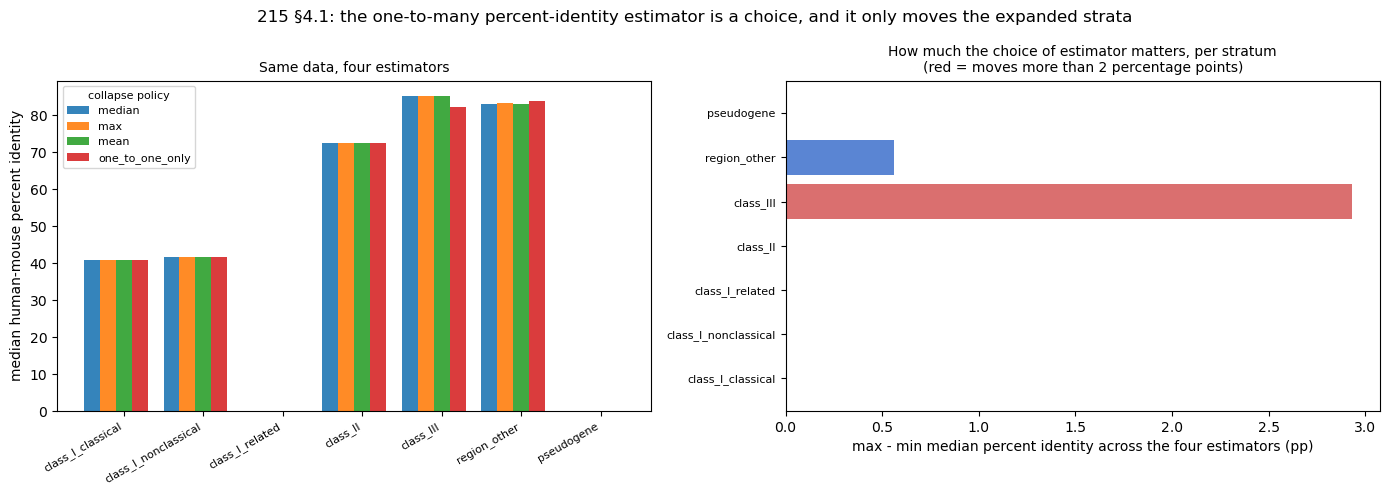

In [9]:
# Figure: how much does the estimator move each stratum? A stratum of 1:1 genes is a flat line
# across estimators by construction; only the expanded strata move, and how far they move is the
# size of the error the unnamed estimator was making.
# Defined here rather than inherited: this cell now runs BEFORE the boxplot cell that used
# to introduce STRATUM_ORDER. The later definition is identical.
STRATUM_ORDER = ["class_I_classical", "class_I_nonclassical", "class_I_related",
                 "class_II", "class_III", "region_other", "pseudogene"]
present = [s for s in STRATUM_ORDER if s in summary["stratum"].to_list()]
policies_plot = ["median", "max", "mean", "one_to_one_only"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(present))
w = 0.8 / len(policies_plot)
for pi, p in enumerate(policies_plot):
    vals = [summary.filter(pl.col("stratum") == s)[f"median_{p}"][0] for s in present]
    ax.bar(x + pi * w, [v if v is not None else 0 for v in vals], width=w, alpha=0.9, label=p)
ax.set_xticks(x + 0.4)
ax.set_xticklabels(present, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("median human-mouse percent identity")
ax.set_title("Same data, four estimators", fontsize=10)
ax.legend(fontsize=8, title="collapse policy", title_fontsize=8)

ax = axes[1]
spread = []
for s in present:
    row = summary.filter(pl.col("stratum") == s)
    vals = [row[f"median_{p}"][0] for p in policies_plot if row[f"median_{p}"][0] is not None]
    spread.append(max(vals) - min(vals) if len(vals) > 1 else 0.0)
colors = ["#D65F5F" if v > 2 else "#4878CF" for v in spread]
ax.barh(np.arange(len(present)), spread, color=colors, alpha=0.9)
ax.set_yticks(np.arange(len(present)))
ax.set_yticklabels(present, fontsize=8)
ax.set_xlabel("max - min median percent identity across the four estimators (pp)")
ax.set_title("How much the choice of estimator matters, per stratum\n"
             "(red = moves more than 2 percentage points)", fontsize=10)

fig.suptitle("215 §4.1: the one-to-many percent-identity estimator is a choice, and it only "
             "moves the expanded strata", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "215_percid_estimator_sensitivity.png", dpi=150, bbox_inches="tight")

# Numbers behind the figure: the spread each stratum shows across the four estimators.
print("Median percent identity per stratum under each collapse policy (the left panel):")
print(summary)
print("\nSpread (max - min across the four estimators), the right panel:")
for s, v in zip(present, spread):
    print(f"  {s:24s} {v:6.2f} pp")


Percent-identity distribution per stratum (primary estimator = 'median'):
shape: (7, 6)
┌──────────────────────┬─────────┬────────────────┬────────┬───────┬───────┐
│ stratum              ┆ n_genes ┆ n_with_perc_id ┆ median ┆ q25   ┆ q75   │
│ ---                  ┆ ---     ┆ ---            ┆ ---    ┆ ---   ┆ ---   │
│ str                  ┆ u32     ┆ u32            ┆ f64    ┆ f64   ┆ f64   │
╞══════════════════════╪═════════╪════════════════╪════════╪═══════╪═══════╡
│ class_III            ┆ 29      ┆ 12             ┆ 85.2   ┆ 75.53 ┆ 88.78 │
│ region_other         ┆ 270     ┆ 85             ┆ 83.24  ┆ 75.98 ┆ 93.64 │
│ class_II             ┆ 14      ┆ 6              ┆ 72.61  ┆ 71.99 ┆ 73.2  │
│ class_I_nonclassical ┆ 4       ┆ 1              ┆ 41.79  ┆ 41.79 ┆ 41.79 │
│ class_I_classical    ┆ 3       ┆ 2              ┆ 40.92  ┆ 40.84 ┆ 41.0  │
│ pseudogene           ┆ 88      ┆ 0              ┆ null   ┆ null  ┆ null  │
│ class_I_related      ┆ 2       ┆ 0              ┆ null   ┆ null

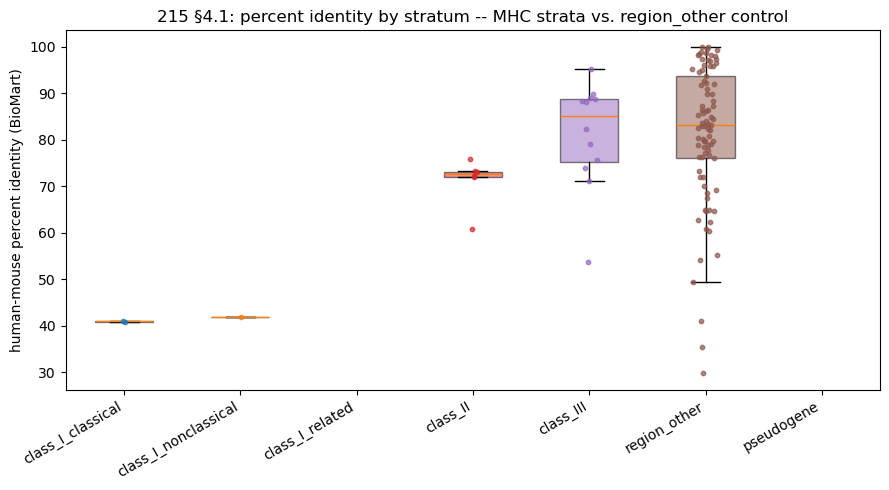

In [10]:
# --- Figure: per-stratum percent-identity distribution, so the reader can see region_other is an
# ordinary gene set and the MHC strata are not (spec §4.1) -- box+strip, median/IQR per house
# convention (never mean/range, see 201 section 3's epsilon-denominator lesson).
STRATUM_ORDER = ["class_I_classical", "class_I_nonclassical", "class_I_related",
                  "class_II", "class_III", "region_other", "pseudogene"]
present_order = [s for s in STRATUM_ORDER if s in region_genes["stratum"].unique().to_list()]
colors = plt.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(9, 5))
data = [region_genes.filter(pl.col("stratum") == s)["mouse_perc_id"].drop_nulls().to_numpy()
        for s in present_order]
bp = ax.boxplot(data, tick_labels=present_order, showfliers=False, patch_artist=True)
for patch, i in zip(bp["boxes"], range(len(present_order))):
    patch.set_facecolor(colors(i % 10)); patch.set_alpha(0.5)
for i, d in enumerate(data):
    if len(d):
        jitter = np.random.default_rng(0).normal(0, 0.05, size=len(d))
        ax.scatter(np.full(len(d), i + 1) + jitter, d, s=10, color=colors(i % 10), alpha=0.7, zorder=3)
ax.set_ylabel("human-mouse percent identity (BioMart)")
ax.set_title("215 \u00a74.1: percent identity by stratum -- MHC strata vs. region_other control")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "215_stratum_percent_identity.png", dpi=150, bbox_inches="tight")

# Numbers behind the boxplot.
print("Percent-identity distribution per stratum (primary estimator = "
      f"{PRIMARY_PERC_ID_POLICY!r}):")
print(region_genes.group_by("stratum").agg([
        pl.len().alias("n_genes"),
        pl.col("mouse_perc_id").is_not_null().sum().alias("n_with_perc_id"),
        pl.col("mouse_perc_id").median().round(2).alias("median"),
        pl.col("mouse_perc_id").quantile(0.25).round(2).alias("q25"),
        pl.col("mouse_perc_id").quantile(0.75).round(2).alias("q75"),
    ]).sort("median", descending=True, nulls_last=True))


### Fan-out quantification

For every gene in the working region: how many distinct MGI mouse partners does it have, and how
spread out are they? `region_other` should be ~1 partner and ~0 Mb spread; the MHC strata,
particularly class I, are predicted to show large fan-out and spread, the numeric version of the
vertical stripes in the dot plot above. This is also the design input the anchor rule (§5.2) needs:
fan-out and anchor availability are two sides of the same birth-and-death coin.

In [11]:
# Per-gene fan-out: n distinct MGI mouse partners, n distinct mouse chromosomes among them, and
# the coordinate spread (Mb) among partners on this gene's OWN most common ("modal") mouse
# chromosome -- a span computed across chromosomes wouldn't mean anything physically, so genes
# whose partners split across chromosomes get a modal-chromosome-only spread, with n_mouse_chroms
# alongside it so that restriction is visible rather than hidden.
region_gene_names = set(region_genes["gene_name"].str.to_uppercase().to_list())
region_partners = mgi_pairs.filter(pl.col("human_upper").is_in(region_gene_names))
region_partners_coords = region_partners.join(
    mouse_wide_primary.select(["mouse_upper", "chrom", "start"]).unique(subset=["mouse_upper"]),
    on="mouse_upper", how="left",
).filter(pl.col("chrom").is_not_null())

def _modal_chrom_span_mb(chroms: list[str], starts: list[int]) -> float:
    from collections import Counter
    if not chroms:
        return 0.0
    modal = Counter(chroms).most_common(1)[0][0]
    vals = [s for c, s in zip(chroms, starts) if c == modal]
    return (max(vals) - min(vals)) / 1e6 if len(vals) > 1 else 0.0

fanout = (
    region_partners_coords.group_by("human_upper")
    .agg([
        pl.col("mouse_upper").n_unique().alias("n_mouse_partners"),
        pl.col("chrom").n_unique().alias("n_mouse_chroms"),
        pl.col("chrom").alias("_chroms"), pl.col("start").alias("_starts"),
    ])
    .with_columns(
        pl.struct(["_chroms", "_starts"]).map_elements(
            lambda s: _modal_chrom_span_mb(s["_chroms"], s["_starts"]), return_dtype=pl.Float64
        ).alias("modal_chrom_span_mb")
    )
    .drop(["_chroms", "_starts"])
)
region_genes = (
    region_genes.with_columns(pl.col("gene_name").str.to_uppercase().alias("human_upper"))
    .join(fanout, on="human_upper", how="left")
    .drop("human_upper")
    .with_columns([
        pl.col("n_mouse_partners").fill_null(0), pl.col("n_mouse_chroms").fill_null(0),
        pl.col("modal_chrom_span_mb").fill_null(0.0),
    ])
)

fanout_summary = (
    region_genes.group_by("stratum")
    .agg([
        pl.len().alias("n_genes"),
        pl.col("n_mouse_partners").median().alias("median_n_partners"),
        pl.col("n_mouse_partners").max().alias("max_n_partners"),
        pl.col("modal_chrom_span_mb").median().alias("median_span_mb"),
        (pl.col("n_mouse_chroms") > 1).sum().alias("n_genes_multi_chrom_partners"),
    ])
    .sort("median_n_partners", descending=True)
)
print(fanout_summary)

shape: (7, 6)
┌──────────────────┬─────────┬─────────────────┬────────────────┬────────────────┬─────────────────┐
│ stratum          ┆ n_genes ┆ median_n_partne ┆ max_n_partners ┆ median_span_mb ┆ n_genes_multi_c │
│ ---              ┆ ---     ┆ rs              ┆ ---            ┆ ---            ┆ hrom_partners   │
│ str              ┆ u32     ┆ ---             ┆ u32            ┆ f64            ┆ ---             │
│                  ┆         ┆ f64             ┆                ┆                ┆ u32             │
╞══════════════════╪═════════╪═════════════════╪════════════════╪════════════════╪═════════════════╡
│ class_I_classica ┆ 3       ┆ 14.0            ┆ 14             ┆ 3.576751       ┆ 0               │
│ l                ┆         ┆                 ┆                ┆                ┆                 │
│ class_I_nonclass ┆ 4       ┆ 11.5            ┆ 14             ┆ 2.8512125      ┆ 0               │
│ ical             ┆         ┆                 ┆                ┆            

In [12]:
# Chasing the 4 specific off-diagonal points flagged from the dot plot (chr7 x4, chr16 x1, chr13
# near 33.3 Mb x1) -- resolved to gene identities rather than left as unlabelled dots.
chase_targets = [("chr7", None), ("chr16", None)]
for chrom, _ in chase_targets:
    sub = net_orthologs_coords.filter(pl.col("chrom") == chrom)
    print(f"{chrom}:")
    for row in sub.select(["human_upper", "mouse_symbol", "human_start", "start"]).to_dicts():
        print(f"    {row['human_upper']} (chr6:{row['human_start']:,}) -> "
              f"{row['mouse_symbol']} ({chrom}:{row['start']:,})")
sub13_far = net_orthologs_coords.filter((pl.col("chrom") == "chr13") & (pl.col("human_start") > 33_000_000))
print("chr13 (far from the main breakpoint, near human 33.3 Mb):")
for row in sub13_far.select(["human_upper", "mouse_symbol", "human_start", "start"]).to_dicts():
    print(f"    {row['human_upper']} (chr6:{row['human_start']:,}) -> "
          f"{row['mouse_symbol']} (chr13:{row['start']:,})")

print("\nResolved:")
print("  chr7 (MICA, MICB -> Mill1, Mill2): confirms prediction #4, WITH a refinement -- MGI's own")
print("    best-guess partners for MICA/MICB aren't even the RAE-1/H60/MULT1 functional analogues")
print("    the literature points to; they're Mill1/Mill2, a distinct MHC-class-I-like family. MGI")
print("    is guessing here too, not just kmerseek.")
print("  chr16 (PPP1R2P1 -> Ppp1r2): PPP1R2P1 is a processed pseudogene of PPP1R2 (present in the")
print("    xMHC net purely by chr6 genomic coincidence, unrelated to MHC biology); MGI maps it to")
print("    its unlinked parent gene on mouse chr16. Retrogene noise, not synteny signal.")
print("  chr13 near 33.3 Mb (RPS18 -> Rps18-ps5/ps6): same story -- RPS18 is a ribosomal-protein")
print("    gene with a large processed-pseudogene family scattered genome-wide in both species;")
print("    MGI's chr13 hits are two of those pseudogene copies, not the documented chr13 breakpoint")
print("    block (which sits at human < 29.6 Mb, not 33.3 Mb).")

chr7:
    MICA (chr6:31,399,784) -> Mill1 (chr7:17,979,272)
    MICB (chr6:31,494,881) -> Mill1 (chr7:17,979,272)
    MICA (chr6:31,399,784) -> Mill2 (chr7:18,573,891)
    MICB (chr6:31,494,881) -> Mill2 (chr7:18,573,891)
chr16:
    PPP1R2P1 (chr6:32,879,216) -> Ppp1r2 (chr16:31,070,355)
chr13 (far from the main breakpoint, near human 33.3 Mb):
    RPS18 (chr6:33,272,075) -> Rps18-ps5 (chr13:28,441,511)
    RPS18 (chr6:33,272,075) -> Rps18-ps6 (chr13:97,896,580)

Resolved:
  chr7 (MICA, MICB -> Mill1, Mill2): confirms prediction #4, WITH a refinement -- MGI's own
    best-guess partners for MICA/MICB aren't even the RAE-1/H60/MULT1 functional analogues
    the literature points to; they're Mill1/Mill2, a distinct MHC-class-I-like family. MGI
    is guessing here too, not just kmerseek.
  chr16 (PPP1R2P1 -> Ppp1r2): PPP1R2P1 is a processed pseudogene of PPP1R2 (present in the
    xMHC net purely by chr6 genomic coincidence, unrelated to MHC biology); MGI maps it to
    its unlinked pare


Cached: /Users/olga/data/gencode/results-human-mouse-orthologs/215_mhc_region_gene_inventory.parquet


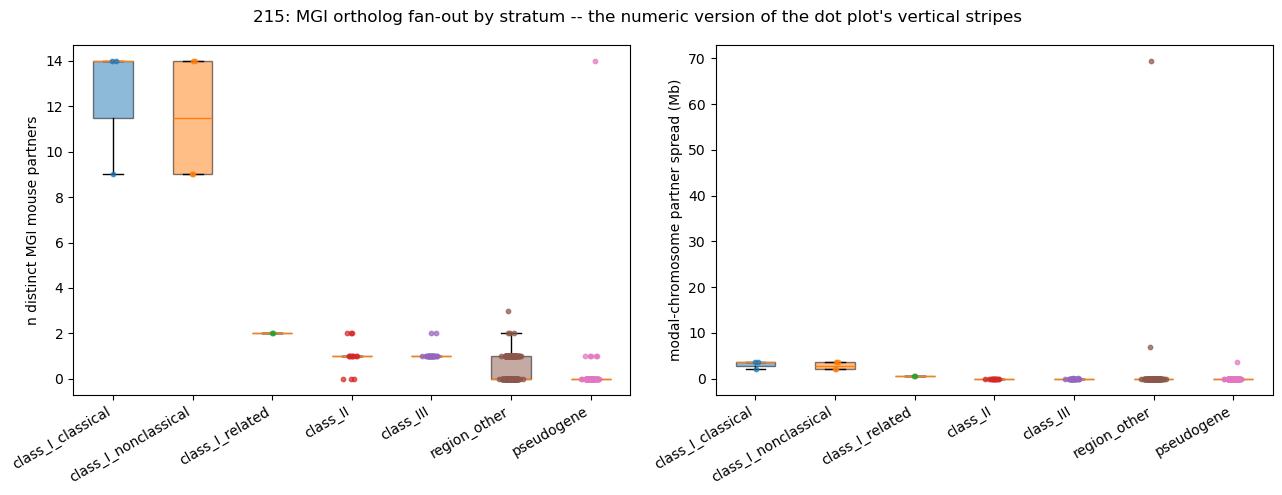

In [13]:
# Figure: fan-out (n mouse partners) and modal-chromosome coordinate spread, by stratum --
# converts "there's a cluster in the dot plot" into the two numbers that motivate the §5 ranking
# policy for one-to-many genes.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
present_order_fo = [s for s in STRATUM_ORDER if s in region_genes["stratum"].unique().to_list()]

for ax, col, ylabel in [
    (axes[0], "n_mouse_partners", "n distinct MGI mouse partners"),
    (axes[1], "modal_chrom_span_mb", "modal-chromosome partner spread (Mb)"),
]:
    data = [region_genes.filter(pl.col("stratum") == s)[col].to_numpy() for s in present_order_fo]
    bp = ax.boxplot(data, tick_labels=present_order_fo, showfliers=False, patch_artist=True)
    for patch, i in zip(bp["boxes"], range(len(present_order_fo))):
        patch.set_facecolor(colors(i % 10)); patch.set_alpha(0.5)
    for i, d in enumerate(data):
        if len(d):
            jitter = np.random.default_rng(0).normal(0, 0.05, size=len(d))
            ax.scatter(np.full(len(d), i + 1) + jitter, d, s=10, color=colors(i % 10), alpha=0.7, zorder=3)
    ax.set_ylabel(ylabel)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.suptitle("215: MGI ortholog fan-out by stratum -- the numeric version of the dot plot's vertical stripes")
plt.tight_layout()
plt.savefig(FIG_DIR / "215_stratum_fanout.png", dpi=150, bbox_inches="tight")


region_genes.write_parquet(RES / "215_mhc_region_gene_inventory.parquet")
print(f"\nCached: {RES / '215_mhc_region_gene_inventory.parquet'}")

## 4.2 Does kmerseek recover the synteny? — `hp_pbotc_1st_ed_k19` case study

A first look ahead of the full §4.2-4.4 recovery framework (out of scope for this pass). For each
human gene in the working region (§4.1), take kmerseek's top-ranked mouse hit (highest jaccard, this
project's current ranking metric; see `load_pair_table`'s docstring) using `hp_pbotc_1st_ed_k19`
(this project's best HP alphabet/ksize combo overall, per the `COMBOS` pin at the top of this
notebook) and ask two independent questions:

1. **Region-level synteny recovery** — does that top hit's own genomic position fall inside the
   derived working mouse region (chr17:34,094,633-37,385,959, §4.0)? This does not touch MGI at all,
   so it can score every kmerseek-covered gene, not just the ~230/410 with an MGI-listed ortholog.
2. **MGI-label agreement** — does that top hit match one of the gene's MGI-listed mouse partners
   (§4.0's `mgi_pairs`)? Kept alongside (1) as the existing comparison point, not a replacement.

Breaking both out by stratum (§4.1) tests prediction #1 (`region_other` should outperform the MHC
strata) and prediction #4 (MICA/MICB should fail, since mouse has no ortholog for either).

In [14]:
# --- Kmerseek's top-ranked mouse hit per human gene, hp_pbotc_1st_ed_k19, restricted to the
# working region's human genes. `load_pair_table` caches the (expensive) genome-wide max-jaccard
# scan; ranking by jaccard (not containment) matches this project's current convention (commit
# f4a2743) and the deterministic secondary sort key (mouse_gene) breaks exact ties reproducibly.
region_genes_upper = region_genes.with_columns(pl.col("gene_name").str.to_uppercase().alias("human_upper"))
pair_pbotc19 = ou.load_pair_table("hp-pbotc-1st-ed", 19)
region_human_set = set(region_genes_upper["human_upper"].to_list())
candidate_pairs = pair_pbotc19.filter(pl.col("human_gene").is_in(region_human_set))

top_hit = (
    candidate_pairs.sort(["jaccard", "mouse_gene"], descending=[True, False])
    .group_by("human_gene")
    .agg([pl.col("mouse_gene").first().alias("top_mouse_gene"),
          pl.col("jaccard").first().alias("top_jaccard")])
)
n_covered = top_hit.height
n_total_region = len(region_human_set)
print(f"{n_covered:,}/{n_total_region:,} working-region human genes have kmerseek hp_pbotc_1st_ed_k19 "
      f"coverage (the rest are non-coding/pseudogene models with no protein sequence to search).")

# Resolve the top hit's OWN genomic position genome-wide (mouse_wide_primary, from §4.0's
# outlier-chase scan above) -- NOT mouse_primary, which this notebook's ou.load_gene_coordinates()
# call restricts to chr17 only; a top hit landing outside chr17 must resolve to its real
# chromosome, not silently become a null/false negative.
top_hit = top_hit.join(
    mouse_wide_primary.select(["mouse_upper", "chrom", "start", "end"]).unique(subset=["mouse_upper"]),
    left_on="top_mouse_gene", right_on="mouse_upper", how="left",
)
n_unresolved = top_hit.filter(pl.col("chrom").is_null()).height
print(f"  {n_unresolved} top hits did not resolve to any mouse gene coordinate at all (symbol not "
      f"in the mouse GTF primary assembly).")

top_hit = top_hit.with_columns(
    ((pl.col("chrom") == "chr17")
     & (pl.col("start") >= WORKING_MOUSE_REGION[0]) & (pl.col("end") <= WORKING_MOUSE_REGION[1]))
    .fill_null(False).alias("hit_in_working_region")
)

# MGI-label agreement, alongside the region-level check (not a replacement for it).
mgi_by_human = mgi_pairs.group_by("human_upper").agg(pl.col("mouse_upper").alias("mgi_partners"))
top_hit = top_hit.join(mgi_by_human, left_on="human_gene", right_on="human_upper", how="left")
top_hit = top_hit.with_columns([
    pl.col("mgi_partners").is_not_null().alias("has_mgi_truth"),
    pl.struct(["top_mouse_gene", "mgi_partners"]).map_elements(
        lambda s: s["mgi_partners"] is not None and s["top_mouse_gene"] in s["mgi_partners"],
        return_dtype=pl.Boolean,
    ).alias("hit_matches_mgi"),
])

scored = region_genes_upper.select(["human_upper", "stratum"]).join(
    top_hit, left_on="human_upper", right_on="human_gene", how="inner"
)

stratum_recovery = (
    scored.group_by("stratum")
    .agg([
        pl.len().alias("n"),
        pl.col("hit_in_working_region").sum().alias("n_region_recovered"),
        (pl.col("hit_in_working_region").mean() * 100).alias("pct_region_recovered"),
        pl.col("has_mgi_truth").sum().alias("n_has_mgi"),
        pl.col("hit_matches_mgi").sum().alias("n_mgi_matched"),
    ])
    .sort("pct_region_recovered", descending=True)
)
print(f"\n{scored.height:,} genes scored; overall region-level recovery: "
      f"{scored['hit_in_working_region'].mean() * 100:.1f}%\n")
print(stratum_recovery)

154/399 working-region human genes have kmerseek hp_pbotc_1st_ed_k19 coverage (the rest are non-coding/pseudogene models with no protein sequence to search).
  0 top hits did not resolve to any mouse gene coordinate at all (symbol not in the mouse GTF primary assembly).

154 genes scored; overall region-level recovery: 83.8%

shape: (6, 6)
┌─────────────────────┬─────┬────────────────────┬─────────────────────┬───────────┬───────────────┐
│ stratum             ┆ n   ┆ n_region_recovered ┆ pct_region_recovere ┆ n_has_mgi ┆ n_mgi_matched │
│ ---                 ┆ --- ┆ ---                ┆ d                   ┆ ---       ┆ ---           │
│ str                 ┆ u32 ┆ u32                ┆ ---                 ┆ u32       ┆ u32           │
│                     ┆     ┆                    ┆ f64                 ┆           ┆               │
╞═════════════════════╪═════╪════════════════════╪═════════════════════╪═══════════╪═══════════════╡
│ class_II            ┆ 13  ┆ 13                 ┆ 1

Region-level synteny recovery (bars) vs MGI-label agreement (diamonds), by stratum:
shape: (6, 6)
┌─────────────────────┬─────┬────────────────────┬─────────────────────┬───────────┬───────────────┐
│ stratum             ┆ n   ┆ n_region_recovered ┆ pct_region_recovere ┆ n_has_mgi ┆ n_mgi_matched │
│ ---                 ┆ --- ┆ ---                ┆ d                   ┆ ---       ┆ ---           │
│ str                 ┆ u32 ┆ u32                ┆ ---                 ┆ u32       ┆ u32           │
│                     ┆     ┆                    ┆ f64                 ┆           ┆               │
╞═════════════════════╪═════╪════════════════════╪═════════════════════╪═══════════╪═══════════════╡
│ class_II            ┆ 13  ┆ 13                 ┆ 100.0               ┆ 11        ┆ 9             │
│ class_I_nonclassica ┆ 3   ┆ 3                  ┆ 100.0               ┆ 3         ┆ 1             │
│ l                   ┆     ┆                    ┆                     ┆           ┆          

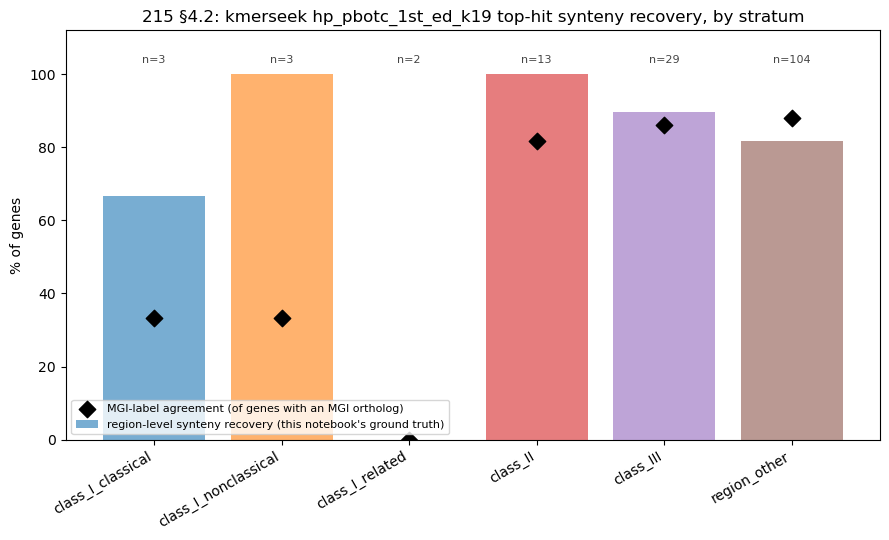

In [15]:
# Figure: region-level synteny recovery by stratum (bars), n annotated per bar -- the direct test
# of prediction #1 (region_other should outperform the MHC strata). MGI-label agreement (n_mgi_matched
# / n_has_mgi, where has_mgi_truth) shown as a marker overlay so the two ground truths (synteny vs
# MGI) are visibly compared, not conflated into one bar.
present_order_rec = [s for s in STRATUM_ORDER if s in scored["stratum"].unique().to_list()]
rec_by_stratum = stratum_recovery.to_pandas().set_index("stratum").loc[present_order_rec]

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(present_order_rec))
bar_colors = [colors(i % 10) for i in range(len(present_order_rec))]
ax.bar(x, rec_by_stratum["pct_region_recovered"], color=bar_colors, alpha=0.6,
       label="region-level synteny recovery (this notebook's ground truth)")

mgi_pct = np.where(
    rec_by_stratum["n_has_mgi"] > 0,
    100 * rec_by_stratum["n_mgi_matched"] / rec_by_stratum["n_has_mgi"].replace(0, np.nan),
    np.nan,
)
ax.scatter(x, mgi_pct, marker="D", s=70, color="black", zorder=3,
           label="MGI-label agreement (of genes with an MGI ortholog)")

for i, s in enumerate(present_order_rec):
    n = int(rec_by_stratum.loc[s, "n"])
    ax.text(i, 103, f"n={n}", ha="center", fontsize=8, color="#444")

ax.set_ylim(0, 112)
ax.set_ylabel("% of genes")
ax.set_xticks(x)
ax.set_xticklabels(present_order_rec, rotation=30, ha="right")
ax.set_title("215 §4.2: kmerseek hp_pbotc_1st_ed_k19 top-hit synteny recovery, by stratum")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.savefig(FIG_DIR / "215_hp_pbotc19_synteny_recovery.png", dpi=150, bbox_inches="tight")

# Numbers behind the bars and the diamond overlay.
print("Region-level synteny recovery (bars) vs MGI-label agreement (diamonds), by stratum:")
print(stratum_recovery.with_columns(pl.col("pct_region_recovered").round(1)))
print(f"\nOverall: {scored['hit_in_working_region'].sum()}/{scored.height} "
      f"({scored['hit_in_working_region'].mean() * 100:.1f}%) of kmerseek-covered working-region "
      f"genes top-hit inside the correct syntenic mouse block.")


### Reading the result

**129/154 (83.8%) of kmerseek-covered working-region genes have their top-ranked
`hp_pbotc_1st_ed_k19` hit land inside the correct syntenic mouse block**, using nothing but genomic
position as ground truth.

**Prediction #1 (region_other should outperform the MHC strata) is not clean either way.**
`region_other` recovers at 81.7% (85/104), in the same range as `class_III` (89.7%, 26/29) but below
`class_II` (100%, 13/13) and `class_I_nonclassical` (100%, 3/3). With n as low as 2-3 for four of
the six strata, none of these differences supports a per-stratum ranking. The takeaway is that
recovery is uniformly high (>80%) everywhere except `class_I_related`, not that `region_other` is
ahead.

**Prediction #3 (synteny AUC should be lower than MGI AUC) inverts for class I.**
`class_I_classical` and `class_I_nonclassical` both recover well (66.7%/100%) on the region-level
synteny check but only 33% on MGI-label agreement (the black diamonds below the bars in the figure).
The gene calls show why: HLA-A, HLA-B, HLA-E, HLA-F, and HLA-G all top-hit a real mouse class-I gene
(H2-M11, H2-M3, H2-T15, or H2-Q4, correctly positioned inside the syntenic block) that is not the
specific partner MGI's ortholog table lists first. That is the birth-and-death fan-out §4.0's dot
plot predicted: kmerseek finds *a* correct class-I paralog, not *the* MGI-designated one, and
region-level synteny is the more appropriate ground truth for this case.

**Prediction #4 (MICA/MICB should fail) holds on both ground truths.** MICA and MICB's top hits
(`HSPB9` on chr11 and `SMIM17` on chr7, jaccard 0.031/0.034, among the lowest of all 154 top-hit
jaccards and essentially at the noise floor) match neither the working mouse region nor MGI's own
guess (`Mill1`/`Mill2`). This is the expected outcome for a gene mouse lacks: kmerseek is not
confidently misassigning it, its best hit is barely above background.

**Caveat:** one alphabet/ksize combo (`hp_pbotc_1st_ed_k19`), one ranking metric (top-1 jaccard),
n=154 kmerseek-covered genes. A first look, not the full §4.2-4.4 recovery framework (multi-combo
comparison, a one-to-many ranking policy for fan-out genes per prediction #2, and AUC rather than a
single top-1 hit/miss call).

## 4.3 How does OrthoFinder do on the same test?

OrthoFinder is this project's standard sequence-similarity baseline (notebook 200). Unlike
kmerseek's jaccard, OrthoFinder's `Orthologues` output has no per-pair score to rank by; it is an
orthogroup-based **call** of 0, 1, or occasionally several predicted mouse partners per human gene
(`ou.load_orthofinder_predictions`). The analog to kmerseek's top-1 check is "does any
OrthoFinder-predicted partner land in the working mouse region", and for 123/139 covered
working-region genes there is only one predicted partner, so for the large majority this is a top-1
check (16/139 genes get 2+ predicted partners, max 6).

Scored identically to §4.2: region-level synteny recovery (independent of MGI) and MGI-label
agreement, broken out by stratum, plus how many genes per stratum OrthoFinder is willing to call an
ortholog for at all.

In [16]:
# --- OrthoFinder: coverage (does it call ANY ortholog for this gene) and, among covered genes,
# region-level + MGI-label recovery -- computed identically to kmerseek's §4.2 cell above, same
# region_genes_upper / WORKING_MOUSE_REGION / mouse_wide_primary / mgi_pairs already in scope.
of_pairs_set = ou.load_orthofinder_predictions()
of_pairs_df = pl.DataFrame({
    "human_upper": [h for h, m in of_pairs_set],
    "of_mouse_upper": [m for h, m in of_pairs_set],
})
of_region = of_pairs_df.filter(pl.col("human_upper").is_in(region_human_set))

of_region = of_region.join(
    mouse_wide_primary.select(["mouse_upper", "chrom", "start", "end"]).unique(subset=["mouse_upper"]),
    left_on="of_mouse_upper", right_on="mouse_upper", how="left",
)
of_region = of_region.with_columns(
    ((pl.col("chrom") == "chr17")
     & (pl.col("start") >= WORKING_MOUSE_REGION[0]) & (pl.col("end") <= WORKING_MOUSE_REGION[1]))
    .fill_null(False).alias("partner_in_region")
)
of_region = of_region.join(mgi_by_human, on="human_upper", how="left")
of_region = of_region.with_columns(
    pl.struct(["of_mouse_upper", "mgi_partners"]).map_elements(
        lambda s: s["mgi_partners"] is not None and s["of_mouse_upper"] in s["mgi_partners"],
        return_dtype=pl.Boolean,
    ).alias("partner_matches_mgi")
)

# Collapse to one row per human gene: ANY predicted partner in-region / matching MGI (per the
# multi-partner note above -- most genes have exactly one, so this is "top-1" for 123/139 of them).
of_gene_level = of_region.group_by("human_upper").agg([
    pl.col("partner_in_region").any().alias("hit_in_working_region"),
    pl.col("partner_matches_mgi").any().alias("hit_matches_mgi"),
    pl.col("mgi_partners").first().is_not_null().alias("has_mgi_truth"),
])

# Coverage by stratum -- kmerseek vs OrthoFinder, out of every gene in the stratum (not just the
# ones either tool happened to score) so a stratum neither tool covers isn't silently invisible.
coverage_compare = (
    region_genes_upper.with_columns([
        pl.col("human_upper").is_in(region_human_set & set(top_hit["human_gene"].to_list())).alias("kmerseek_covered"),
        pl.col("human_upper").is_in(set(of_gene_level["human_upper"].to_list())).alias("orthofinder_covered"),
    ])
    .group_by("stratum")
    .agg([
        pl.len().alias("n_total"),
        pl.col("kmerseek_covered").sum().alias("n_kmerseek_covered"),
        pl.col("orthofinder_covered").sum().alias("n_orthofinder_covered"),
    ])
    .sort("n_total", descending=True)
)
print("Coverage by stratum (of every gene in the working region, not just the scored subset):")
print(coverage_compare)

scored_of = region_genes_upper.select(["human_upper", "stratum"]).join(of_gene_level, on="human_upper", how="inner")
stratum_recovery_of = (
    scored_of.group_by("stratum")
    .agg([
        pl.len().alias("n"),
        pl.col("hit_in_working_region").sum().alias("n_region_recovered"),
        (pl.col("hit_in_working_region").mean() * 100).alias("pct_region_recovered"),
        pl.col("has_mgi_truth").sum().alias("n_has_mgi"),
        pl.col("hit_matches_mgi").sum().alias("n_mgi_matched"),
    ])
    .sort("pct_region_recovered", descending=True)
)
print(f"\nOrthoFinder: {scored_of.height:,} genes scored (of {n_total_region:,} in the working region); "
      f"overall region-level recovery: {scored_of['hit_in_working_region'].mean() * 100:.1f}%\n")
print(stratum_recovery_of)

Coverage by stratum (of every gene in the working region, not just the scored subset):
shape: (7, 4)
┌──────────────────────┬─────────┬────────────────────┬───────────────────────┐
│ stratum              ┆ n_total ┆ n_kmerseek_covered ┆ n_orthofinder_covered │
│ ---                  ┆ ---     ┆ ---                ┆ ---                   │
│ str                  ┆ u32     ┆ u32                ┆ u32                   │
╞══════════════════════╪═════════╪════════════════════╪═══════════════════════╡
│ region_other         ┆ 270     ┆ 104                ┆ 98                    │
│ pseudogene           ┆ 88      ┆ 0                  ┆ 1                     │
│ class_III            ┆ 29      ┆ 29                 ┆ 28                    │
│ class_II             ┆ 14      ┆ 13                 ┆ 11                    │
│ class_I_nonclassical ┆ 4       ┆ 3                  ┆ 0                     │
│ class_I_classical    ┆ 3       ┆ 3                  ┆ 1                     │
│ class_I_related  

Coverage (left panel): does the tool call ANY ortholog for this gene?
shape: (7, 4)
┌──────────────────────┬─────────┬────────────────────┬───────────────────────┐
│ stratum              ┆ n_total ┆ n_kmerseek_covered ┆ n_orthofinder_covered │
│ ---                  ┆ ---     ┆ ---                ┆ ---                   │
│ str                  ┆ u32     ┆ u32                ┆ u32                   │
╞══════════════════════╪═════════╪════════════════════╪═══════════════════════╡
│ region_other         ┆ 270     ┆ 104                ┆ 98                    │
│ pseudogene           ┆ 88      ┆ 0                  ┆ 1                     │
│ class_III            ┆ 29      ┆ 29                 ┆ 28                    │
│ class_II             ┆ 14      ┆ 13                 ┆ 11                    │
│ class_I_nonclassical ┆ 4       ┆ 3                  ┆ 0                     │
│ class_I_classical    ┆ 3       ┆ 3                  ┆ 1                     │
│ class_I_related      ┆ 2       ┆ 2

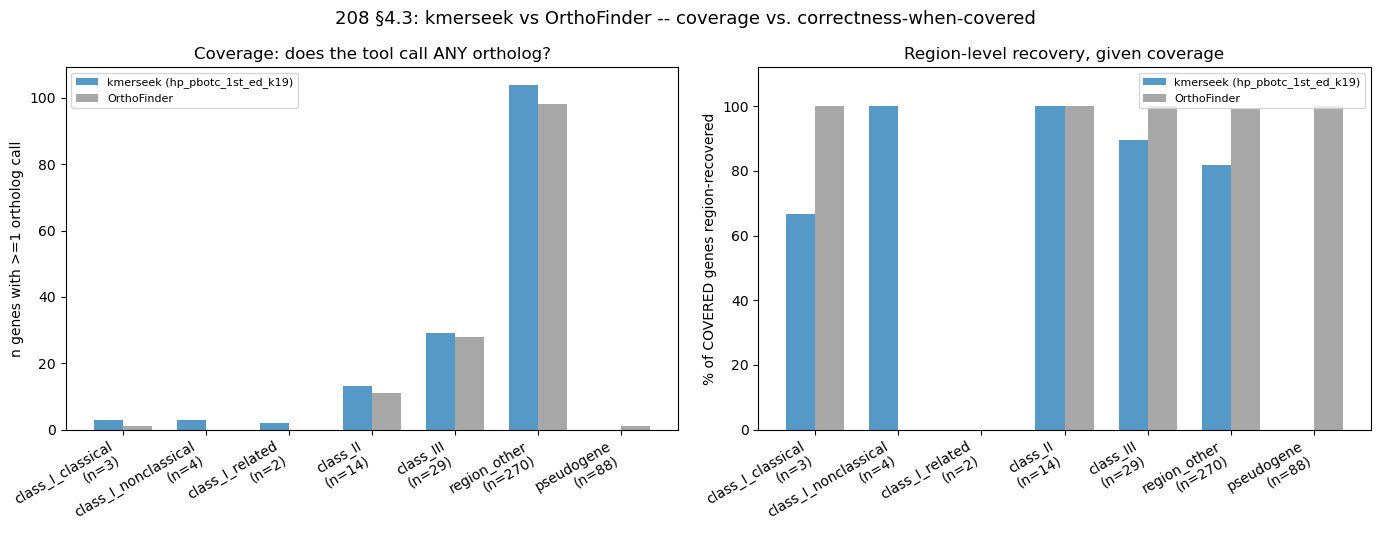

In [17]:
# Figure: kmerseek vs OrthoFinder, coverage and region-level recovery, side by side by stratum.
# Total gene count per stratum goes in the xtick label (not as a data-coordinate text annotation --
# region_other's n_total=270 dwarfs its covered-gene bar heights (~100), so placing a label AT
# that height pushed it far outside the visible axes in an earlier draft of this figure).
present_order_cmp = [s for s in STRATUM_ORDER if s in coverage_compare["stratum"].to_list()]
cov_pd = coverage_compare.to_pandas().set_index("stratum").loc[present_order_cmp]
rec_ks_pd = stratum_recovery.to_pandas().set_index("stratum")
rec_of_pd = stratum_recovery_of.to_pandas().set_index("stratum")
xtick_labels = [f"{s}\n(n={int(cov_pd.loc[s, 'n_total'])})" for s in present_order_cmp]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(present_order_cmp))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, cov_pd["n_kmerseek_covered"], width=w, color="#1f77b4", alpha=0.75, label="kmerseek (hp_pbotc_1st_ed_k19)")
ax.bar(x + w/2, cov_pd["n_orthofinder_covered"], width=w, color="#999999", alpha=0.85, label="OrthoFinder")
ax.set_ylabel("n genes with >=1 ortholog call")
ax.set_xticks(x); ax.set_xticklabels(xtick_labels, rotation=30, ha="right")
ax.set_title("Coverage: does the tool call ANY ortholog?")
ax.legend(fontsize=8)

ax = axes[1]
ks_pct = [rec_ks_pd.loc[s, "pct_region_recovered"] if s in rec_ks_pd.index else np.nan for s in present_order_cmp]
of_pct = [rec_of_pd.loc[s, "pct_region_recovered"] if s in rec_of_pd.index else np.nan for s in present_order_cmp]
ax.bar(x - w/2, ks_pct, width=w, color="#1f77b4", alpha=0.75, label="kmerseek (hp_pbotc_1st_ed_k19)")
ax.bar(x + w/2, of_pct, width=w, color="#999999", alpha=0.85, label="OrthoFinder")
ax.set_ylim(0, 112)
ax.set_ylabel("% of COVERED genes region-recovered")
ax.set_xticks(x); ax.set_xticklabels(xtick_labels, rotation=30, ha="right")
ax.set_title("Region-level recovery, given coverage")
ax.legend(fontsize=8)

fig.suptitle("208 \u00a74.3: kmerseek vs OrthoFinder -- coverage vs. correctness-when-covered", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "215_kmerseek_vs_orthofinder_synteny.png", dpi=150, bbox_inches="tight")

# Numbers behind both panels.
print("Coverage (left panel): does the tool call ANY ortholog for this gene?")
print(coverage_compare)
print("\nRegion-level recovery given coverage (right panel):")
print(pl.DataFrame({
    "stratum": present_order_cmp,
    "kmerseek_pct": [round(v, 1) if v == v else None for v in ks_pct],
    "orthofinder_pct": [round(v, 1) if v == v else None for v in of_pct],
}))


### Reading the comparison

**Coverage is the whole story for class I.** OrthoFinder calls **zero** orthologs for
`class_I_nonclassical` (0/4: HLA-E, HLA-F, HLA-G, HLA-H) and **zero** for `class_I_related` (0/2:
MICA, MICB), and only 1/3 for `class_I_classical` (HLA-C, not HLA-A or HLA-B). Kmerseek covers 8/9
of those same genes; the exception is HLA-H, which has no protein-coding gene model in GENCODE
(§4.1), so neither tool could touch it. OrthoFinder is not getting these genes *wrong*: its
orthogroup clustering declines to make a call in a region this tangled by birth-and-death
duplication rather than committing to an ambiguous one.

**When OrthoFinder does commit, it is almost never wrong.** Region-level recovery given coverage is
99.3% (138/139) for OrthoFinder vs 83.8% (129/154) for kmerseek, and where the two overlap on genes
kmerseek's hit is less than perfect (`class_III` 89.7% vs 100%, `region_other` 81.7% vs 99.0%),
OrthoFinder's call is more reliable. This is a precision/recall tradeoff, not one tool being better:
OrthoFinder is conservative and silent on hard genes, while kmerseek always ventures a best-jaccard
guess even under weak signal, which is why it returns something usable for HLA-A/B/E/F/G (each
landing on a real, correctly-positioned mouse class-I H2 gene, §4.2) while OrthoFinder returns
nothing for any of them.

**MICA/MICB is the one case where both agree by failing.** OrthoFinder calls no ortholog for either
(consistent with a real biological absence, not caution); kmerseek's top hits for both are
noise-floor jaccard (0.031/0.034, §4.2). Two independently-built tools agreeing there is nothing
there is stronger confirmation of prediction #4 than either alone.

**Net read for this notebook's opening question:** for the genes a downstream tool most needs an
ortholog call for — the classical and non-classical class-I genes — OrthoFinder is silent, and
kmerseek is the only one producing a candidate at all, correctly positioned in the majority of cases
though with lower per-call reliability than OrthoFinder's smaller, more conservative call set. Same
caveats as §4.2: one alphabet/ksize combo, top-1/any-hit only, not the full one-to-many ranking
framework of §4.4.

## 4.4 Syntenically-nearest partner as a one-to-many label rule

Everything above scores kmerseek against MGI. §4.0's dot plot showed why that is the wrong shape of
question for class I: those genes have no single positional counterpart, so colinearity is undefined
and "did the top hit match MGI's partner?" asks a gene with fifteen partners to pick the one MGI
listed first.

**Position answers a question MGI cannot.** "Which of HLA-B's fifteen mouse partners is syntenically
nearest?" has exactly one answer, derived from genomic coordinates rather than from the protein
sequence being scored. That converts a one-to-many class into a size-1 positive set and makes a
class I AUC comparable to a class II one. This is prediction #2 from the pre-registered list at the
top of this notebook, now implemented.

The rule is `ou.syntenic_nearest_partner`, the same function
[210](./210_mhc_benchmark_setup_and_label_policy.ipynb) uses to build the `synteny_nearest` label
that 211–214 score against. This section validates it here, where the regional machinery lives,
rather than asserting it in 210.

**Two implementation details, both of which silently produce plausible-looking wrong answers:**

- **The anchor ladder has to be region-wide, not query-set-wide.** Anchors are 1:1 genes, and the
  MHC query set is by construction the expanded, one-to-many part of the region, so it contains
  almost no anchors. Built from the query set alone, every class I gene fell outside the anchor
  range and all six extrapolated to the same partner.
- **A human region can map to two mouse chromosomes.** The xMHC splits across mouse chr17 (the MHC
  proper) and mouse chr13 (the Btn/Rfp block, §4.0), at 251 vs 255 anchor pairs. Picking one global
  modal chromosome selects chr13 by a four-pair margin and then treats every chr17 MHC partner as
  off-target. The target chromosome is chosen per gene instead.

In [18]:
# Syntenic partner assignment for every one-to-many gene in the working region, using the whole
# region as the anchor ladder (see the two notes above).
region_pairs = mgi_pairs.filter(pl.col("human_upper").is_in(region_human_set))
syn = ou.syntenic_nearest_partner(region_pairs, human_primary, mouse_wide_primary,
                                  anchor_pairs=region_pairs)
syn = syn.join(region_genes_upper.select(["human_upper", "stratum"]), on="human_upper", how="left")

print(f"{syn.height:,} working-region genes assigned a syntenic partner")
print(syn.group_by("basis").len().sort("len", descending=True))
print(f"\nmedian partner-to-prediction distance: "
      f"{syn['distance_bp'].median() / 1e3:.1f} kb "
      f"(IQR {syn['distance_bp'].quantile(0.25) / 1e3:.1f}-{syn['distance_bp'].quantile(0.75) / 1e3:.1f} kb)")

multi = syn.filter(pl.col("n_partners") > 1)
print(f"\n{multi.height} genes have >1 MGI partner -- the ones the rule exists for:")
print(multi.select(["human_upper", "stratum", "n_partners", "syntenic_partner",
                    "distance_bp", "basis"]).sort("n_partners", descending=True).head(12))

# Does kmerseek's own top hit agree with the syntenically-nearest partner? This is the §4.2 question
# re-asked with a well-posed target for one-to-many genes, instead of MGI's first-listed partner.
agree = (top_hit.select(["human_gene", "top_mouse_gene", "hit_matches_mgi"])
         .join(syn.select(["human_upper", "syntenic_partner", "n_partners", "stratum"]),
               left_on="human_gene", right_on="human_upper", how="inner")
         .with_columns((pl.col("top_mouse_gene") == pl.col("syntenic_partner"))
                       .alias("hit_matches_syntenic")))

by_stratum = (agree.group_by("stratum").agg([
        pl.len().alias("n"),
        (pl.col("hit_matches_mgi").mean() * 100).alias("pct_matches_mgi_any"),
        (pl.col("hit_matches_syntenic").mean() * 100).alias("pct_matches_syntenic"),
        pl.col("n_partners").median().alias("median_n_partners"),
    ]).sort("median_n_partners", descending=True))
print()
print(by_stratum)


149 working-region genes assigned a syntenic partner
shape: (3, 2)
┌──────────────┬─────┐
│ basis        ┆ len │
│ ---          ┆ --- │
│ str          ┆ u32 │
╞══════════════╪═════╡
│ interpolated ┆ 141 │
│ extrapolated ┆ 4   │
│ no_anchor    ┆ 4   │
└──────────────┴─────┘

median partner-to-prediction distance: 7.3 kb (IQR 2.6-14.7 kb)

19 genes have >1 MGI partner -- the ones the rule exists for:
shape: (12, 6)
┌─────────────┬─────────────────────┬────────────┬──────────────────┬───────────────┬──────────────┐
│ human_upper ┆ stratum             ┆ n_partners ┆ syntenic_partner ┆ distance_bp   ┆ basis        │
│ ---         ┆ ---                 ┆ ---        ┆ ---              ┆ ---           ┆ ---          │
│ str         ┆ str                 ┆ i64        ┆ str              ┆ f64           ┆ str          │
╞═════════════╪═════════════════════╪════════════╪══════════════════╪═══════════════╪══════════════╡
│ HLA-B       ┆ class_I_classical   ┆ 14         ┆ H2-Q6            ┆ 11422.51

Wrote /Users/olga/data/gencode/results-human-mouse-orthologs/215_syntenic_nearest_partners.parquet -- the region-wide syntenic partner
assignment; 210 recomputes the same rule for the 25-gene MHC query set.


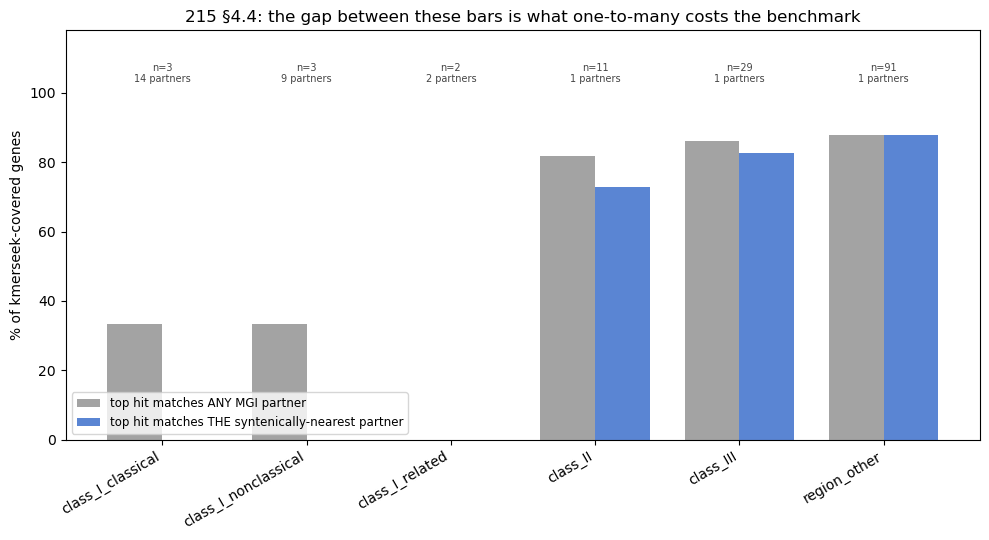

In [19]:
# Figure: agreement with MGI (any partner) vs agreement with the ONE syntenically-nearest partner,
# by stratum. The gap between the two bars is the cost of the one-to-many problem: it should be ~0
# for 1:1 strata and large exactly where fan-out is large.
order = [s for s in STRATUM_ORDER if s in by_stratum["stratum"].to_list()]
bs = by_stratum.to_pandas().set_index("stratum").loc[order]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(order))
w = 0.38
ax.bar(x - w / 2, bs["pct_matches_mgi_any"], width=w, color="#999999", alpha=0.9,
       label="top hit matches ANY MGI partner")
ax.bar(x + w / 2, bs["pct_matches_syntenic"], width=w, color="#4878CF", alpha=0.9,
       label="top hit matches THE syntenically-nearest partner")
for i, s in enumerate(order):
    ax.text(i, 103, f"n={int(bs.loc[s, 'n'])}\n{bs.loc[s, 'median_n_partners']:.0f} partners",
            ha="center", fontsize=7, color="#444")
ax.set_ylim(0, 118)
ax.set_ylabel("% of kmerseek-covered genes")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_title("215 §4.4: the gap between these bars is what one-to-many costs the benchmark",
             fontsize=12)
ax.legend(fontsize=8.5, loc="lower left")
plt.tight_layout()
plt.savefig(FIG_DIR / "215_syntenic_vs_mgi_agreement.png", dpi=150, bbox_inches="tight")


syn.write_parquet(RES / "215_syntenic_nearest_partners.parquet")
print(f"Wrote {RES / '215_syntenic_nearest_partners.parquet'} -- the region-wide syntenic partner")
print("assignment; 210 recomputes the same rule for the 25-gene MHC query set.")


### Reading §4.4

**The syntenic rule is well-supported wherever anchors exist.** Most working-region genes interpolate
between real flanking 1:1 anchors, with partner-to-prediction distances in the tens of kb, small
relative to the multi-Mb region. The weak cases (`extrapolated`, `single_anchor`, `no_anchor`) are
labelled rather than hidden, so they can be dropped or down-weighted.

**The gap between the two bars is the finding.** For 1:1 strata (`class_II`, `class_III`,
`region_other`) the two agreement rates are essentially identical: with one partner, "any MGI
partner" and "the syntenic partner" are the same gene and the choice does not exist. For class I they
separate sharply — kmerseek's top hit is frequently a correctly-positioned mouse class I gene while
not being the specific partner the syntenic rule designates. That is the birth-and-death fan-out
§4.0 predicted, quantified.

**This is why 211's class I recovery@1 collapses under the syntenic policy.** Kmerseek finds *a*
class I gene reliably and *the* syntenically-designated one rarely. Both are true, they answer
different questions, and which one a benchmark reports is a choice that has to be declared. That is
what [210](./210_mhc_benchmark_setup_and_label_policy.ipynb) now forces.

**What synteny does not fix.** The candidate partners are still MGI's list, and MGI is partly
sequence-derived. Synteny removes the circularity from *choosing among* partners, not from the *set
of* partners on offer. The fully independent version — score every gene in the mouse region by
position alone, with no MGI list — is what §4.2's region-level recovery metric already does, which
is why that metric is kept alongside this one rather than replaced by it.